# FPV attenuation factor analysis

Author: Sofia Midauar

Date: January 2025

In [1]:
import pandas as pd
import xarray as xr
import glob2 as glob
from scipy.interpolate import interp1d
import numpy as np
import os
from matplotlib import pyplot as plt
import seaborn as sns
import re
import matplotlib.dates as mdates
from osgeo import ogr # conda install gdal
import calendar

In [2]:
%config Completer.use_jedi = False

In [3]:
# pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Define functions

In [4]:
def is_fpv(x, y, polys):
    """Returns a boolean mask array representing the presence of FPV-covered grid points.
    `x` and `y` are 2D arrays with x and y coordinates.
    `polys` must be an iterable of osgeo.ogr.Geometry objects from a shapefile.
    """
    def is_in_polys(x, y):
        point = ogr.Geometry(ogr.wkbPoint)
        point.AddPoint(x, y)
        for poly in polys:
            if point.Within(poly):
                return True
        return False
    is_in_polys = np.vectorize(is_in_polys)
    return is_in_polys(x, y)

In [5]:
def create_fpv_mask(xcenters, ycenters, fpv_shp_file):
    """Returns a boolean mask array representing the presence of FPV-covered grid points.
     `xcenters` and `ycenters` are 2D arrays with x and y cell center coordinates. They can be obtained from XZ and XZ coordinates of a trim-*.nc file.
     `fpv_shp_file` is a path to a shapefile.
    """
    ds = ogr.Open(fpv_shp_file)
    layer = ds.GetLayer(0)
    polys = []
    for i in range(layer.GetFeatureCount()):
        feature = layer.GetFeature(i)
        geom = feature.geometry().Clone()
        polys.append(geom)

    return is_fpv(xcenters, ycenters, polys)

In [6]:
def season_of_date(date_UTC):
    """Returns season for given datetime"""
    year = str(pd.to_datetime(date_UTC.strftime('%Y-%m-%d')).year)
    seasons = {'spring': pd.date_range(start= pd.to_datetime(year +'-03-21'), end=pd.to_datetime(year + '-06-20')),
               'summer': pd.date_range(start= pd.to_datetime(year + '-06-21'), end= pd.to_datetime(year + '-09-22')),
               'autumn': pd.date_range(start= pd.to_datetime(year + '-09-23'), end= pd.to_datetime(year + '-12-20')),
               'winter': pd.date_range(start= pd.to_datetime(year + '-12-21'), end= pd.to_datetime(year + '-03-20'))}
    if (pd.to_datetime(year +'-03-21') <= date_UTC <= pd.to_datetime(year + '-06-20')):
        return 'spring'
    elif (pd.to_datetime(year +'-06-21') <= date_UTC <= pd.to_datetime(year + '-09-22')):
        return 'summer'
    elif (pd.to_datetime(year +'-09-23') <= date_UTC <= pd.to_datetime(year + '-12-20')):
        return 'autumn'
    else:
        return 'winter'

# Temperature

In [7]:
# folder path to save figures
figs_path = 'C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/results/figures_FPV/FPV_factors_vf_comp/'

In [8]:
# Creates list with depth of measurements
depth_obs = [0.5, 1, 2, 3, 4, 5, 6, 7]
depth_obs_str = []

for i in depth_obs:
    name = (str(i) + 'm')
    depth_obs_str.append(name)
    
depth_obs_str

['0.5m', '1m', '2m', '3m', '4m', '5m', '6m', '7m']

In [9]:
folder_runs = '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/FPV_attenuation_factor/vf/'
output_paths = sorted(glob.glob(folder_runs + '*/', recursive = True))


In [10]:
# Read folder locations for all the runs 
folder_runs = '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/FPV_attenuation_factor/vf/'
output_paths = sorted(glob.glob(folder_runs + '*/', recursive = True))

Dictionary_WT_underFPV = {}

for folder in range(len(output_paths)):
    names = glob.glob(output_paths[folder] + 'trim*.nc')
    output = xr.open_dataset(names[0])
    output_temp_underFPV = output[["R1", "ZK_LYR", "S1"]].isel(LSTSCI = 0, M = 20, N = 32)
    output_temp_underFPV["DK_LYR"] = output_temp_underFPV.S1 - output_temp_underFPV.ZK_LYR
    data_modelled = np.empty((len(output_temp_underFPV.time.values), 8))
    # calculates temperature per depth (matching measurements) for each timestep
    for i in range(len(output_temp_underFPV.time.values)):
        output_temp_underFPV_t = output_temp_underFPV.isel(time = i) # subsets for timestep analysed
        depth = output_temp_underFPV_t.DK_LYR.values # gets depth values of modelled temperature
        temp = output_temp_underFPV_t.R1.values # gets water temperature value
        time = output_temp_underFPV_t.time.values # gets timestep analysed
        temp = temp[depth > 0] # gets temperature values for depth > 0
        depth = depth[depth > 0] # gets depth values > 0
        f = interp1d(depth, temp, fill_value = "extrapolate") # creates function to interp WT values according to depth
        data_modelled[i, :] = f(depth_obs) # creates array with WT values per depth (matching measurements), for each timestep
    # Creates new dataframe with information on time and depth of the modelled temperature
    WT_underFPV_modelled = pd.DataFrame(data_modelled)
    times_t = pd.DataFrame(output_temp_underFPV.time.values)
    WT_underFPV_modelled['time'] = times_t
    WT_underFPV_modelled.set_index('time', inplace = True)
    WT_underFPV_modelled.columns = depth_obs_str
    # creates dictionary with all model outputs from the multiple attenuation factors
    name = (os.path.basename(names[0])[24:-3])
    Dictionary_WT_underFPV[name] = WT_underFPV_modelled.copy()

Dictionary_WT_underFPV

{'factor1':                           0.5m         1m         2m         3m         4m  \
 time                                                                         
 2022-09-09 00:00:00  25.645449  25.591359  25.478496  25.359496  25.392140   
 2022-09-09 06:00:00  25.185508  25.192014  25.202716  25.209000  25.212645   
 2022-09-09 12:00:00  25.186158  25.194370  25.207578  25.214180  25.200924   
 2022-09-09 18:00:00  25.172107  25.182053  25.198012  25.206333  25.207990   
 2022-09-10 00:00:00  24.893789  24.900587  24.911711  24.918244  24.922222   
 ...                        ...        ...        ...        ...        ...   
 2024-03-14 00:00:00  10.051177  10.030047   9.684963   9.167169   8.651733   
 2024-03-14 06:00:00  11.094680  11.072684  10.433621   9.531924   8.894052   
 2024-03-14 12:00:00  10.549717  10.549057  10.486977   9.918580   9.183633   
 2024-03-14 18:00:00  10.196389  10.205460  10.217034  10.050225   9.389370   
 2024-03-15 00:00:00  10.006040  10.01198

In [11]:
Dictionary_WT_underFPV['factor050'] = Dictionary_WT_underFPV['9']
del Dictionary_WT_underFPV['9']
Dictionary_WT_underFPV.keys()

dict_keys(['factor1', 'sr05wnd060', 'sr05wnd070', 'sr06wnd050', 'factor060', 'sr06wnd070', 'sr07wnd050', 'sr07wnd060', 'factor070', 'factor050'])

In [12]:
Dictionary_WT_underFPV = dict(sorted(Dictionary_WT_underFPV.items()))
Dictionary_WT_underFPV.keys()

dict_keys(['factor050', 'factor060', 'factor070', 'factor1', 'sr05wnd060', 'sr05wnd070', 'sr06wnd050', 'sr06wnd070', 'sr07wnd050', 'sr07wnd060'])

# Compare runs

In [13]:
# Creates df with bias - one column per depth
runs_names = ['factor050', 'sr05wnd060', 'sr05wnd070', 'factor060', 'sr06wnd050', 'sr06wnd070', 
              'factor070',  'sr07wnd050', 'sr07wnd060', 'factor1']
WT_noFPV_underFPV = Dictionary_WT_underFPV['factor1'].copy()
Dictionary_bias_underFPV = {}

# Add columns for other depths
for run in runs_names[:-1]:
    temporary = Dictionary_WT_underFPV[run].copy()
    temp_bias = pd.DataFrame(temporary.index)
    temp_bias.set_index('time', inplace = True)
    for depth in range(0, len(depth_obs), 1):
        temp_bias['bias_' + depth_obs_str[depth]] = (temporary[temporary.columns[depth]] - 
                                                     WT_noFPV_underFPV[WT_noFPV_underFPV.columns[depth]])
    temp_bias['averaged_bias'] = temp_bias.mean(axis=1)
    Dictionary_bias_underFPV[(run + '_bias')] = temp_bias.copy()

Dictionary_bias_underFPV

{'factor050_bias':                      bias_0.5m   bias_1m   bias_2m   bias_3m   bias_4m  \
 time                                                                     
 2022-09-09 00:00:00   0.000000  0.000000  0.000000  0.000000  0.000000   
 2022-09-09 06:00:00   0.006448  0.006199  0.005792  0.005530  0.005258   
 2022-09-09 12:00:00  -0.041486 -0.042522 -0.043632 -0.042525 -0.024580   
 2022-09-09 18:00:00  -0.071929 -0.074832 -0.079026 -0.080019 -0.076971   
 2022-09-10 00:00:00  -0.044678 -0.045601 -0.046862 -0.046998 -0.046331   
 ...                        ...       ...       ...       ...       ...   
 2024-03-08 18:00:00  -2.825732 -2.825397 -2.542457 -2.479471 -2.368058   
 2024-03-09 00:00:00  -2.706202 -2.677031 -2.661907 -2.500145 -2.380825   
 2024-03-09 06:00:00  -2.645088 -2.630740 -2.624217 -2.388235 -2.443383   
 2024-03-09 12:00:00  -2.568263 -2.556985 -2.559367 -2.496540 -2.404795   
 2024-03-09 18:00:00  -2.562506 -2.553364 -2.533774 -2.543542 -2.410758   
 
     

In [14]:
# Adjusts format for boxplot
runs = list(Dictionary_bias_underFPV.keys())
Dictionary_bias_boxplot_underFPV = {}

for run in range(0, len(runs),1):
    temp_completo = Dictionary_bias_underFPV[runs[run]].copy()
    for depth in range(len(depth_obs)+1):
        temp = pd.DataFrame(temp_completo[temp_completo.columns[depth]])
        temp.rename(columns = {temp.columns[0]:'bias'}, inplace = True)
        try:
            temp['depth'] = depth_obs[depth]
        except:
            temp['depth'] = 'average'
        temp['run_ID'] = runs[run]
        if depth == 0:
            WT_bias_boxplot_underFPV = temp.copy()
        else:
            WT_bias_boxplot_underFPV = pd.concat([WT_bias_boxplot_underFPV, temp])
    
    Dictionary_bias_boxplot_underFPV[runs[run] + 'boxplot'] = WT_bias_boxplot_underFPV.copy()

Dictionary_bias_boxplot_underFPV

{'factor050_biasboxplot':                          bias    depth          run_ID
 time                                                  
 2022-09-09 00:00:00  0.000000      0.5  factor050_bias
 2022-09-09 06:00:00  0.006448      0.5  factor050_bias
 2022-09-09 12:00:00 -0.041486      0.5  factor050_bias
 2022-09-09 18:00:00 -0.071929      0.5  factor050_bias
 2022-09-10 00:00:00 -0.044678      0.5  factor050_bias
 ...                       ...      ...             ...
 2024-03-08 18:00:00 -2.629833  average  factor050_bias
 2024-03-09 00:00:00 -2.615215  average  factor050_bias
 2024-03-09 06:00:00 -2.591120  average  factor050_bias
 2024-03-09 12:00:00 -2.572897  average  factor050_bias
 2024-03-09 18:00:00 -2.575924  average  factor050_bias
 
 [19728 rows x 3 columns],
 'sr05wnd060_biasboxplot':                          bias    depth           run_ID
 time                                                   
 2022-09-09 00:00:00  0.000000      0.5  sr05wnd060_bias
 2022-09-09 06:00:00 

In [15]:
runs_bp = list(Dictionary_bias_boxplot_underFPV.keys())

for run in runs_bp:
    temp = Dictionary_bias_boxplot_underFPV[run].copy()
    temp = temp[temp['depth'] != 'average']
    if run == runs_bp[0]:
        joined_df_boxplot = temp.copy()
    else:
        joined_df_boxplot = pd.concat([joined_df_boxplot, temp])

joined_df_boxplot.head(2)

,bias,depth,run_ID
time,,,
2022-09-09 00:00:00,0.000000,0.5,factor050_bias
2022-09-09 06:00:00,0.006448,0.5,factor050_bias


In [16]:
runs_bp = list(Dictionary_bias_boxplot_underFPV.keys())

for run in runs_bp:
    temp = Dictionary_bias_boxplot_underFPV[run].copy()
    temp = temp[temp['depth'] == 'average']
    if run == runs_bp[0]:
        joined_df_bp_average = temp.copy()
    else:
        joined_df_bp_average = pd.concat([joined_df_bp_average, temp])

joined_df_bp_average.head(2)

,bias,depth,run_ID
time,,,
2022-09-09 00:00:00,0.000000,average,factor050_bias
2022-09-09 06:00:00,0.004274,average,factor050_bias


# Calculation of PEA

In [8]:
# Folder path for model output FPV scenarios - varying attenuation factor
# path_output = '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/FPV_attenuation_factor/vf/*/'
# folders = sorted(glob.glob(path_output))

# trim_files = []

# for run in range(len(folders)):
#     temp = (folders[run] + 'trim*.nc')
#     path = glob.glob(temp)
#     trim_files.append(path[0])

# trim_files[0]

'//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/FPV_attenuation_factor/vf\\00_noFPV\\trim-FPV_nocover_eqgrid_factor1.nc'

In [9]:
# read output files and create array with only data that is under the FPV
# temp_rho_dic = {}
# shapefile = '//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/lake_water_surface_right.shp' # shapefile for PEA

# for run in range(0,len(trim_files)):
#     if run == 0:
#         name = 'no_FPV'
#     else:
#         name = trim_files[run][85:94]
#     ds = xr.open_dataset(trim_files[run])
#     ds["DK_LYR"] = ds.S1 - ds.ZK_LYR # creates attribute with output depth
#     ds["DK"] = ds.S1 - ds.ZK
#     mask = create_fpv_mask(ds.XZ, ds.YZ, shapefile)
#     ind_calc_PEA = np.argwhere(mask) # list of pairs (m,n) where mask is True
#     temp = ds[['RHO', 'DK_LYR', 'DK']]
#     temp_rho_dic[name] = temp.copy()

# temp_rho_dic.keys()

dict_keys(['no_FPV'])

In [74]:
# scenarios = list(temp_rho_dic.keys())

# for scen in range(len(scenarios)):
#     name = scenarios[scen]
    
#     ### doing only one scenario
#     temp_rho = temp_rho_dic[scenarios[scen]].copy()
#     g = 9.81

#     # prepare storage
#     n_time = temp_rho.sizes['time'] # gets number of timesteps
#     n_cells = len(ind_calc_PEA) # gets number of grid cells
#     PEA_results = np.full((n_time, n_cells), np.nan) # creates an empty array with y as long as timesteps and x as grid cells

#     for i in range(n_time):
#         temp_time = temp_rho.isel(time=i)
#         current_time = temp_time.time.values

#         for j, cell in enumerate(ind_calc_PEA):
#             temp_cell = temp_time.isel(M=cell[0], N=cell[1])

#             depth = temp_cell.DK_LYR.values
#             max_depth = temp_cell.DK.values  # This might be a 1D array
#             rho = temp_cell.RHO.values

#             # mask inactive or invalid values
#             mask = (depth > 0) & (rho > 0)
#             if np.count_nonzero(mask) <= 1: # if there's only one active layer, PEA is ZERO. if there's no active layer, PEA is NaN
#                 PEA_results[i, j] = 0 if np.count_nonzero(mask) == 1 else np.nan
#                 continue

#             depth = depth[mask]
#             rho = rho[mask]
#             delta_depth = np.diff(depth, prepend = np.nan)  # emulate .diff() but keep length
#             valid = ~np.isnan(delta_depth) # Create a mask to filter out NaN values in delta_depth

#             mean_rho = np.sum(rho[valid] * delta_depth[valid]) / np.sum(delta_depth[valid])
#             to_sum = (mean_rho - rho[valid]) * g * depth[valid] * delta_depth[valid]

#             # Handle the case where max_depth is a 1D array, take the first value
#             if np.ndim(max_depth) > 0:
#                 max_depth = max_depth[0]

#             PEA = (1 / max_depth) * np.sum(to_sum)
#             PEA_results[i, j] = PEA  # Ensure PEA is a scalar

#     pd.DataFrame(PEA_results).to_csv('varyingalpha_PEA_' + name + '.csv')

# Import PEA csvs

In [7]:
PEA_csvs = sorted(glob.glob('varyingalpha_PEA_*.csv')) # list output PEA files
PEA_csvs

['varyingalpha_PEA_no_FPV.csv',
 'varyingalpha_PEA_sr05wnd05.csv',
 'varyingalpha_PEA_sr05wnd06.csv',
 'varyingalpha_PEA_sr05wnd07.csv',
 'varyingalpha_PEA_sr06wnd05.csv',
 'varyingalpha_PEA_sr06wnd06.csv',
 'varyingalpha_PEA_sr06wnd07.csv',
 'varyingalpha_PEA_sr07wnd05.csv',
 'varyingalpha_PEA_sr07wnd06.csv',
 'varyingalpha_PEA_sr07wnd07.csv']

In [10]:
times = pd.DataFrame(temp_rho_dic['no_FPV'].time.values, columns = ['time'])

labels = ['No FPV',
          f'α = 0.5', f'α_sr = 0.5, α_wind = 0.6', f'α_sr = 0.5, α_wind = 0.7',
          f'α_sr = 0.6, α_wind = 0.5', f'α = 0.6', f'α_sr = 0.6, α_wind = 0.7',
          f'α_sr = 0.7, α_wind = 0.5', f'α_sr = 0.7, α_wind = 0.6', f'α = 0.7']

for scen in range(0, len(PEA_csvs), 1):
    temp_PEA = pd.read_csv(PEA_csvs[scen]).iloc[:, 1:] # read csv for PEA
    name = labels[scen]
    
    temp_PEA[name] = temp_PEA.max(axis = 1)
    temp_PEA = temp_PEA[temp_PEA.columns[[-1]]]
    temp_PEA['time'] = times['time']
    
    if scen == 0:
        PEA_df = temp_PEA.copy()
    else:
        PEA_df = pd.merge(PEA_df, temp_PEA, on = 'time', how = "inner")

PEA_df.set_index('time', inplace = True)
PEA_df.head(2)

,No FPV,α = 0.5,"α_sr = 0.5, α_wind = 0.6","α_sr = 0.5, α_wind = 0.7","α_sr = 0.6, α_wind = 0.5",α = 0.6,"α_sr = 0.6, α_wind = 0.7","α_sr = 0.7, α_wind = 0.5","α_sr = 0.7, α_wind = 0.6",α = 0.7
time,,,,,,,,,,
2022-09-09 00:00:00,1.166554,1.166554,1.166554,1.166554,1.166554,1.166554,1.166554,1.166554,1.166554,1.166554
2022-09-09 06:00:00,0.521636,0.528595,0.526570,0.525466,0.528595,0.526570,0.525466,0.528595,0.526570,0.525466


In [11]:
summary_PEA_scen = PEA_df.resample('M').mean()
summary_PEA_scen = summary_PEA_scen.loc['2023-04-30':'2023-08-31'].T
summary_PEA_scen['average'] = summary_PEA_scen.mean(axis = 1)
summary_PEA_scen = pd.DataFrame(summary_PEA_scen['average'])
summary_PEA_scen

,average
No FPV,7.676270
α = 0.5,9.946425
"α_sr = 0.5, α_wind = 0.6",9.748854
"α_sr = 0.5, α_wind = 0.7",9.475157
"α_sr = 0.6, α_wind = 0.5",10.092650
α = 0.6,9.830728
"α_sr = 0.6, α_wind = 0.7",9.532527
"α_sr = 0.7, α_wind = 0.5",10.102905
"α_sr = 0.7, α_wind = 0.6",9.819995
α = 0.7,9.490016


In [12]:
## DATAFRAME FOR CREATING BOXPLOTS
ndepths = 9 # number of model output time series per depth
scenarios = list(PEA_df.columns)

for scen in range(len(scenarios)):
    temporary = pd.DataFrame(PEA_df[scenarios[scen]].copy())

    temporary.reset_index(inplace = True)
    temporary.rename(columns = {temporary.columns[0]:'time', temporary.columns[1]:'PEA'}, inplace = True)
    temporary['scenario'] = scenarios[scen]
    # Join result to dataframe with control run output for comparison
    if (scen == 0):
        bp_PEA_comp = temporary.copy()
    else:
        bp_PEA_comp = pd.concat([bp_PEA_comp, temporary])

bp_PEA_comp['time'] = pd.to_datetime(bp_PEA_comp['time'])
bp_PEA_comp.set_index('time', inplace = True)
# # Creates columns with month
bp_PEA_comp['month'] = bp_PEA_comp.index.month
bp_PEA_comp['year'] = bp_PEA_comp.index.year
bp_PEA_comp['year'] = bp_PEA_comp['year'].apply(lambda x: str(x)[2:])
bp_PEA_comp['month_str'] = ((bp_PEA_comp['month'].apply(lambda x: calendar.month_abbr[x])) + 
                            (bp_PEA_comp['year']))
bp_PEA_comp.reset_index(drop = False, inplace = True)
bp_PEA_comp['season'] = bp_PEA_comp['time'].apply(season_of_date)
# bp_PEA_comp.reset_index(drop = True, inplace = True)
bp_PEA_comp.head(2)

,time,PEA,scenario,month,year,month_str,season
0,2022-09-09 00:00:00,1.166554,No FPV,9,22,Sep22,summer
1,2022-09-09 06:00:00,0.521636,No FPV,9,22,Sep22,summer


In [156]:
bp_PEA_comp.scenario.unique()

array(['No FPV', 'α = 0.5', 'α_sr = 0.5, α_wind = 0.6',
       'α_sr = 0.5, α_wind = 0.7', 'α_sr = 0.6, α_wind = 0.5', 'α = 0.6',
       'α_sr = 0.6, α_wind = 0.7', 'α_sr = 0.7, α_wind = 0.5',
       'α_sr = 0.7, α_wind = 0.6', 'α = 0.7'], dtype=object)

# Plots - PEA

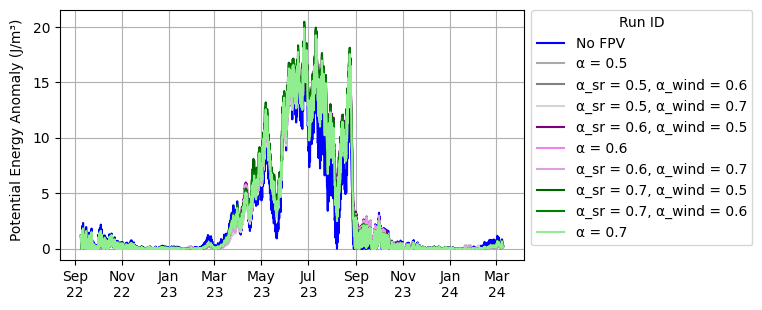

In [165]:
colours = ['blue',
           'darkgrey','grey','lightgrey',
           'purple', 'violet', 'plum', 
           'darkgreen', 'green', 'lightgreen']

# Plot time series raw data for WT among scenarios
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [7.5,3.2], sharex = True, sharey = True)

for scen in range(len(PEA_df.columns)):
    ax.plot(PEA_df.index, PEA_df[PEA_df.columns[scen]], 
            color = colours[scen], label = PEA_df.columns[scen])

ax.grid(True)
ax.legend(title = "Run ID", ncol = 1, fontsize = 10, frameon = True, columnspacing = 1, 
          bbox_to_anchor=(1, 1.03))

# Add formatted date labels
myFmt = mdates.DateFormatter('%b\n%y')
ax.xaxis.set_major_formatter(myFmt)

fig.text(-0.010, 0.58, u'Potential Energy Anomaly (J/m³)', 
         va='center', rotation='vertical')

plt.subplots_adjust(wspace = 0, hspace = 0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig('PEA_varyingalpha_timeseries.jpeg', dpi=300, bbox_inches='tight')

plt.show();

In [132]:
bp_PEA_comp["scenario"].unique()

array(['No FPV', 'α_sr = 0.5, α_wind = 0.5', 'α_sr = 0.5, α_wind = 0.6',
       'α_sr = 0.5, α_wind = 0.7', 'α_sr = 0.6, α_wind = 0.5',
       'α_sr = 0.6, α_wind = 0.6', 'α_sr = 0.6, α_wind = 0.7',
       'α_sr = 0.7, α_wind = 0.5', 'α_sr = 0.7, α_wind = 0.6',
       'α_sr = 0.7, α_wind = 0.7'], dtype=object)

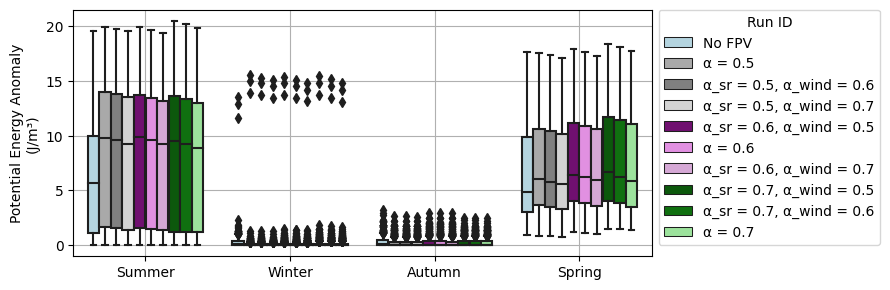

In [164]:
# Plot time series raw data for WT among scenarios
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [9,3], sharex = True, sharey = True)
pal = sns.color_palette("tab10", 20)

palette = {
    'No FPV': 'lightblue',
    'α = 0.5': 'darkgrey',
    'α_sr = 0.5, α_wind = 0.6': 'grey',
    'α_sr = 0.5, α_wind = 0.7': 'lightgrey',
    'α_sr = 0.6, α_wind = 0.5':'purple',
    'α = 0.6':'violet',
    'α_sr = 0.6, α_wind = 0.7':'plum',
    'α_sr = 0.7, α_wind = 0.5':'darkgreen',
    'α_sr = 0.7, α_wind = 0.6':'green',
    'α = 0.7':'lightgreen'
}

sns.boxplot(x = "season", y = "PEA", 
            data = bp_PEA_comp,
            width = 0.8, boxprops = {'zorder': 2}, palette = palette, ax = ax, hue = 'scenario')

ax.grid(True)

ax.yaxis.set_label_text(u'Potential Energy Anomaly\n(J/m³)', fontsize = 10)
ax.xaxis.set_label_text(u'')

ax.legend(title = "Run ID", ncol = 1, fontsize = 10, frameon = True, columnspacing = 1, 
          bbox_to_anchor=(1, 1.03))

ax.set_xticks([0,1,2,3],
              ['Summer', 'Winter', 'Autumn', 'Spring'],
              fontsize = 10)

plt.subplots_adjust(wspace = 0, hspace = 0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig('PEA_varyingalpha_bp_seasons.jpeg', dpi=300, bbox_inches='tight')

plt.show();

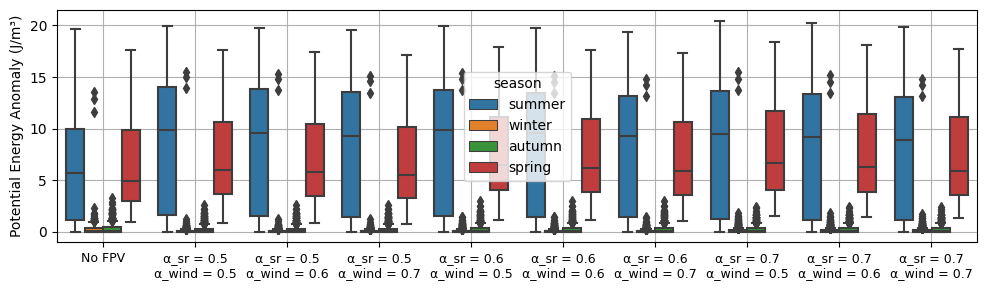

In [112]:
# Plot time series raw data for WT among scenarios
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [10,3], sharex = True, sharey = True)
pal = sns.color_palette("tab10", 20)

sns.boxplot(x = "scenario", y = "PEA", 
            data = bp_PEA_comp,
            width = 0.8, boxprops = {'zorder': 2}, palette = pal[0:8], ax = ax, hue = 'season')

ax.grid(True)

ax.yaxis.set_label_text(u'Potential Energy Anomaly (J/m³)', fontsize = 10)
ax.xaxis.set_label_text(u'')

ax.set_xticks([0,1,2,3,4,5,6,7,8,9],
              ['No FPV',
               f'α_sr = 0.5\nα_wind = 0.5', f'α_sr = 0.5\nα_wind = 0.6', f'α_sr = 0.5\nα_wind = 0.7',
               f'α_sr = 0.6\nα_wind = 0.5', f'α_sr = 0.6\nα_wind = 0.6', f'α_sr = 0.6\nα_wind = 0.7',
               f'α_sr = 0.7\nα_wind = 0.5', f'α_sr = 0.7\nα_wind = 0.6', f'α_sr = 0.7\nα_wind = 0.7'],
              fontsize = 9)

plt.subplots_adjust(wspace = 0, hspace = 0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(path_figures + 'FPV_scen_WT_bp_depth.jpeg', dpi=600, bbox_inches='tight')

plt.show();

# Plots

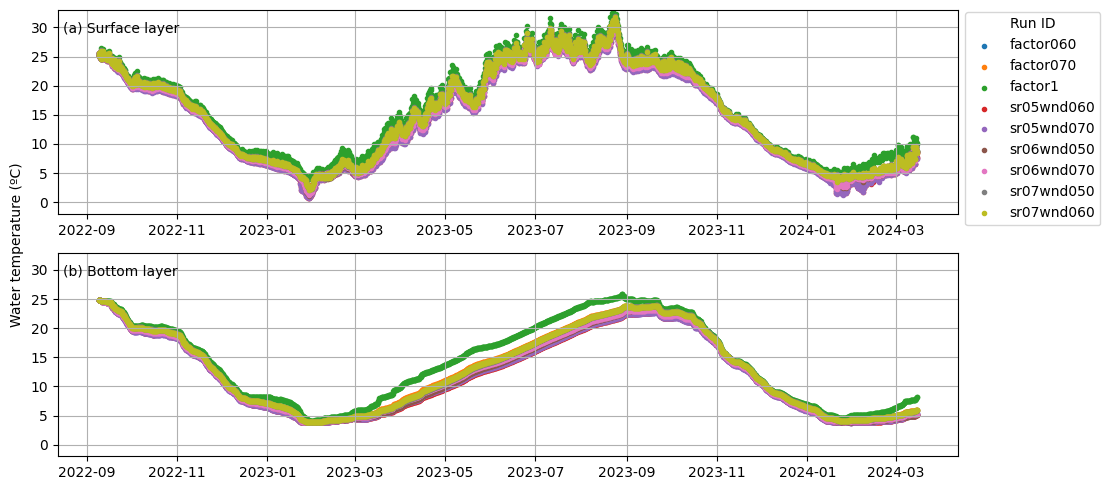

In [20]:
# Plot graph with bias per depth - SURFACE LAYER
fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = [11,5])
pal = sns.color_palette("tab10", 11)
# ax[0].get_xlim()[0] # line to check xaxis limits (0 - start, -1 - end)
 
legends = ['0.5m', '1m', '2m', '3m', '4m', '5m', '6m', '7m']
runs = list(Dictionary_WT_underFPV.keys())

for run in range(1, len(runs), 1):
    temp_plot = Dictionary_WT_underFPV[runs[run]].copy()
    ax[0].scatter(temp_plot.index, temp_plot[temp_plot.columns[0]],
               marker = '.', color = pal.as_hex()[run-1], zorder = 1, 
               label = runs[run])
    ax[0].grid(True, zorder = -1)
    ax[0].set_ylim(-2, 33)

for run in range(1, len(runs), 1):
    temp_plot = Dictionary_WT_underFPV[runs[run]].copy()
    ax[1].scatter(temp_plot.index, temp_plot[temp_plot.columns[-2]],
               marker = '.', color = pal.as_hex()[run-1], zorder = 1, 
               label = runs[run])
    ax[1].grid(True, zorder = -1)  
    ax[1].set_ylim(-2, 33)

ax[0].legend(title = "Run ID", ncol = 1, fontsize = 10, 
          frameon = True, columnspacing = 1, bbox_to_anchor=(1.0, 1.025))
ax[0].text(19220, 29, '(a) Surface layer')
ax[1].text(19220, 29, '(b) Bottom layer')

plt.subplots_adjust(wspace = 0, hspace = 0)

fig.text(-0.005, 0.5, u'Water temperature (ºC)', va='center', rotation='vertical')

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
plt.savefig(figs_path + 'WT_surface_bottom.jpeg', dpi = 300, bbox_inches = 'tight')

plt.show();

In [144]:
runs

['factor050_bias',
 'sr05wnd060_bias',
 'sr05wnd070_bias',
 'factor060_bias',
 'sr06wnd050_bias',
 'sr06wnd070_bias',
 'factor070_bias',
 'sr07wnd050_bias',
 'sr07wnd060_bias']

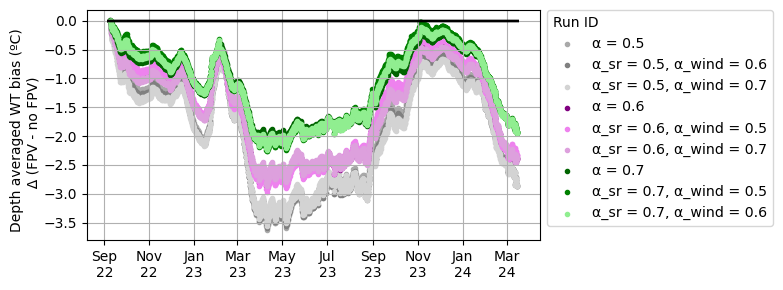

In [24]:
colours = ['darkgrey','grey','lightgrey',
           'purple', 'violet', 'plum', 
           'darkgreen', 'green', 'lightgreen']

# Plot graph with bias per depth
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [7.6,3])
pal = sns.color_palette("tab10", 11)
# ax[0].get_xlim()[0] # line to check xaxis limits (0 - start, -1 - end)

legends = ['0.5m', '1m', '2m', '3m', '4m', '5m', '6m', '7m']
runs = list(Dictionary_bias_underFPV.keys())

# Organise labeling 
alphas = []

for s in runs:
    if s.startswith('factor'):
        num = int(re.search(r'\d+', s).group()) / 100
        alphas.append(f'α = {num:g}')
    elif s.startswith('sr'):
        nums = re.findall(r'\d+', s)
        if len(nums) == 2:
            alpha_r = int(nums[0]) / 10    # sr number (05 → 0.5)
            alpha_w = int(nums[1]) / 100   # wnd number (060 → 0.6)
            alphas.append(f'α_sr = {alpha_r:g}, α_wind = {alpha_w:g}')

# Plot the data

for run in range(0, len(runs), 1):
    temp_plot = Dictionary_bias_underFPV[runs[run]].copy()
    ax.scatter(temp_plot.index, temp_plot[temp_plot.columns[-1]],
               marker = '.', color = colours[run], zorder = 1, 
               label = alphas[run])
    ax.hlines(y = 0, xmin = 19240, xmax = 19800, color = 'k')
    ax.grid(True, zorder = -1)

ax.legend(title = "Run ID", loc="lower left", ncol = 1, fontsize = 10.2, 
               frameon = True, columnspacing = 0.01, bbox_to_anchor=(1, 0.03))._legend_box.align = "left"

# Add formatted date labels
myFmt = mdates.DateFormatter('%b\n%y')
ax.xaxis.set_major_formatter(myFmt)

# ax.set_ylim(-0.5,0.6)

plt.subplots_adjust(wspace = 0, hspace = 0)

fig.text(-0.024, 0.55, u'Depth averaged WT bias (ºC)\n          Δ (FPV - no FPV)', va='center', rotation='vertical')

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(figs_path + 'bias_WT_depthaveraged.jpeg', dpi = 300, bbox_inches = 'tight')

plt.show();

In [22]:
figs_path

'C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/results/figures_FPV/FPV_factors_vf_comp/'

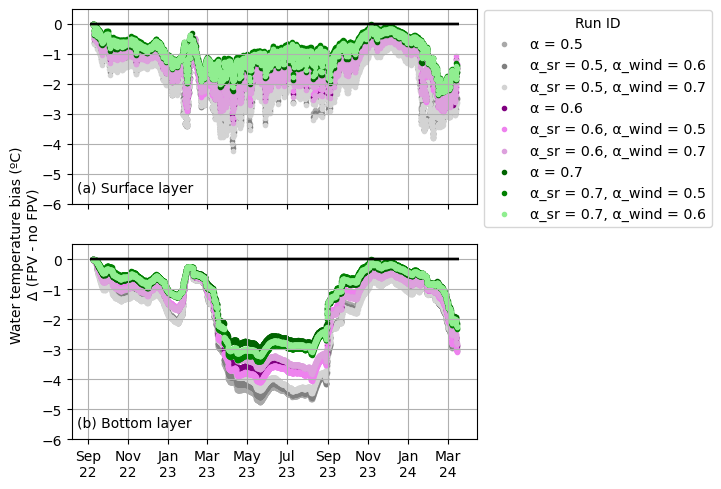

In [31]:
colours = ['darkgrey','grey','lightgrey',
           'purple', 'violet', 'plum', 
           'darkgreen', 'green', 'lightgreen']

# Plot graph with bias per depth - SURFACE LAYER
fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = [7,5], sharex = True)
pal = sns.color_palette("tab10", 11)
# ax[0].get_xlim()[0] # line to check xaxis limits (0 - start, -1 - end)
 
legends = ['0.5m', '1m', '2m', '3m', '4m', '5m', '6m', '7m']
runs = list(Dictionary_bias_underFPV.keys())

# Organise labeling 
alphas = []

for s in runs:
    if s.startswith('factor'):
        num = int(re.search(r'\d+', s).group()) / 100
        alphas.append(f'α = {num:g}')
    elif s.startswith('sr'):
        nums = re.findall(r'\d+', s)
        if len(nums) == 2:
            alpha_r = int(nums[0]) / 10    # sr number (05 → 0.5)
            alpha_w = int(nums[1]) / 100   # wnd number (060 → 0.6)
            alphas.append(f'α_sr = {alpha_r:g}, α_wind = {alpha_w:g}')

# plot data
for run in range(0, len(runs), 1):
    temp_plot = Dictionary_bias_underFPV[runs[run]].copy()
    ax[0].scatter(temp_plot.index, temp_plot[temp_plot.columns[0]],
               marker = '.', color = colours[run], zorder = 1, 
               label = alphas[run])
    ax[0].hlines(y = 0, xmin = 19240, xmax = 19800, color = 'k')
    ax[0].grid(True, zorder = -1)
    ax[0].set_ylim(-6, 0.5)

for run in range(0, len(runs), 1):
    temp_plot = Dictionary_bias_underFPV[runs[run]].copy()
    ax[1].scatter(temp_plot.index, temp_plot[temp_plot.columns[-2]],
               marker = '.', color = colours[run], zorder = 1, 
               label = alphas[run])
    ax[1].hlines(y = 0, xmin = 19240, xmax = 19800, color = 'k')
    ax[1].grid(True, zorder = -1)  
    ax[1].set_ylim(-6, 0.5)

ax[0].legend(title = "Run ID", ncol = 1, fontsize = 10.3, 
          frameon = True, columnspacing = 1, bbox_to_anchor=(1.0, 1.03))
ax[0].text(19220, -5.6, '(a) Surface layer')
ax[1].text(19220, -5.6, '(b) Bottom layer')

# Add formatted date labels
myFmt = mdates.DateFormatter('%b\n%y')
ax[1].xaxis.set_major_formatter(myFmt)

plt.subplots_adjust(wspace = 0, hspace = 0)

fig.text(-0.024, 0.5, u'Water temperature bias (ºC)\n          Δ (FPV - no FPV)', va='center', rotation='vertical')

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(figs_path + 'bias_WT_surface_bottom.jpeg', dpi = 300, bbox_inches = 'tight')

plt.show();

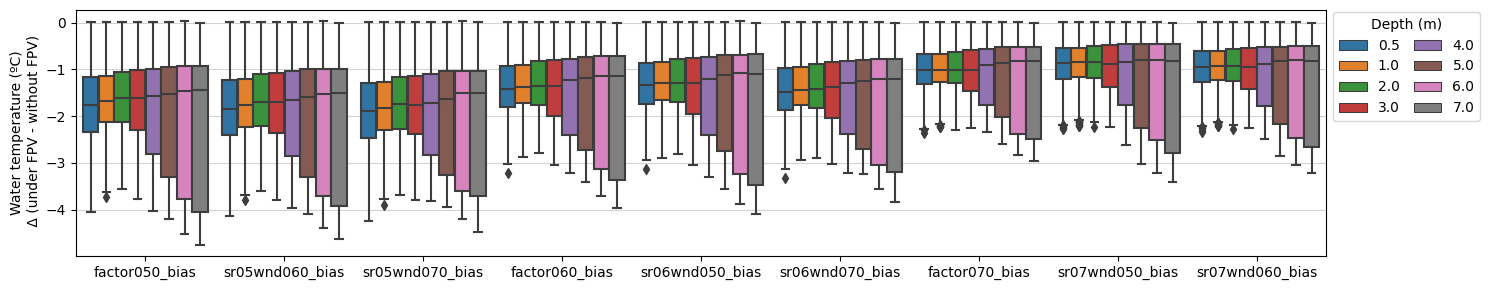

In [23]:
# Plot graph with delta between scenarios and control run
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [15,3])

pal = sns.color_palette("tab10",10)
depths = WT_bias_boxplot_underFPV['depth'].unique().tolist()

sns.boxplot(x = "run_ID", y = "bias", 
            data = joined_df_boxplot,
            width = 0.9, boxprops = {'zorder': 2}, palette = pal[0:9], ax = ax, hue = 'depth')

ax.set_xticks(list(range(0, len(runs), 1)), runs,
              fontsize = 10) 
ax.xaxis.set_label_text("")
ax.tick_params(axis = 'y', which = 'major', labelsize = 10)

ax.yaxis.set_label_text(u'Water temperature (ºC)\n Δ (under FPV - without FPV)', fontsize = 10)
ax.legend(title = "Depth (m)", ncol = 2, fontsize = 10, 
          frameon = True, columnspacing = 1, bbox_to_anchor=(1.0, 1.02))

ax.set_axisbelow(True)
ax.grid(color='lightgray', axis = 'y')

plt.subplots_adjust(wspace=0, hspace=0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
plt.savefig(figs_path + 'bias_WT_perdepth_boxplot.jpeg', dpi = 300, bbox_inches = 'tight')
plt.show();

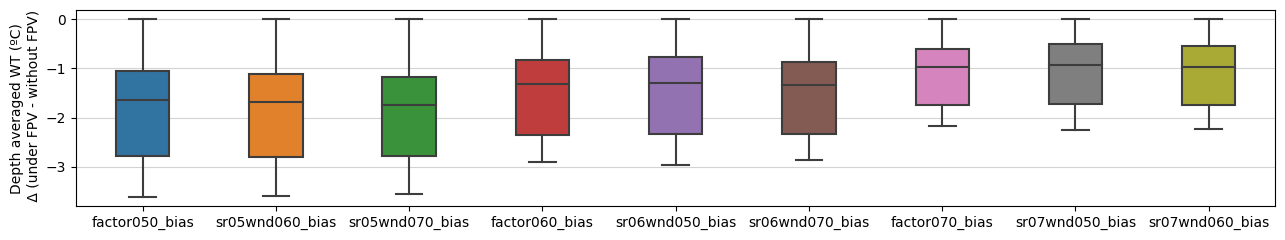

In [24]:
# Plot graph with delta between scenarios and control run
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [13,2.5])

pal = sns.color_palette("tab10",10)
depths = WT_bias_boxplot_underFPV['depth'].unique().tolist()

sns.boxplot(x = "run_ID", y = "bias", 
            data = joined_df_bp_average,
            width = 0.4, boxprops = {'zorder': 2}, palette = pal[0:9], ax = ax)

ax.set_xticks(list(range(0, len(runs), 1)), runs,
              fontsize = 10) 
ax.xaxis.set_label_text("")
ax.tick_params(axis = 'y', which = 'major', labelsize = 10)

ax.yaxis.set_label_text(u'Depth averaged WT (ºC)\n Δ (under FPV - without FPV)', fontsize = 10)

ax.set_axisbelow(True)
ax.grid(color='lightgray', axis = 'y')

plt.subplots_adjust(wspace=0, hspace=0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
plt.savefig(figs_path + 'bias_WT_depthaveraged_boxplot.jpeg', dpi = 300, bbox_inches = 'tight')
plt.show();

# Obsolete

In [6]:
output = xr.open_dataset(output_files[0] + 'trim-FPV_cover49_eqgrid_factor045.nc')

In [8]:
# Creates file with temperature data for specific location
# R1: water temperature | ZK_LYR: Vertical coordinates of layer centres | S1: Water-level in zeta point
output_temp_underFPV = output[["R1", "ZK_LYR", "S1"]].isel(LSTSCI = 0, M = 20, N = 32)

In [9]:
# Creates variable with depth of zeta point (S1: Water-level in zeta point - ZK_LYR: Vertical coordinates of layer centres)
output_temp_underFPV["DK_LYR"] = output_temp_underFPV.S1 - output_temp_underFPV.ZK_LYR

In [10]:
# Creates empty array with dimensions matching (timesteps, measurement points length)
data_modelled = np.empty((len(output_temp_underFPV.time.values), 8))

# calculates temperature per depth (matching measurements) for each timestep
for i in range(len(output_temp_underFPV.time.values)):
    output_temp_underFPV_t = output_temp_underFPV.isel(time = i) # subsets for timestep analysed
    depth = output_temp_underFPV_t.DK_LYR.values # gets depth values of modelled temperature
    temp = output_temp_underFPV_t.R1.values # gets water temperature value
    time = output_temp_underFPV_t.time.values # gets timestep analysed
    temp = temp[depth > 0] # gets temperature values for depth > 0
    depth = depth[depth > 0] # gets depth values > 0
    f = interp1d(depth, temp, fill_value = "extrapolate") # creates function to interp WT values according to depth
    data_modelled[i, :] = f(depth_obs) # creates array with WT values per depth (matching measurements), for each timestep

In [11]:
# Creates new dataframe with information on time and depth of the modelled temperature
WT_underFPV_modelled = pd.DataFrame(data_modelled)
times_t = pd.DataFrame(output_temp_underFPV.time.values)
WT_underFPV_modelled['time'] = times_t
WT_underFPV_modelled.set_index('time', inplace = True)
WT_underFPV_modelled.columns = depth_obs_str
WT_underFPV_modelled.head(2)

,0.5m,1m,2m,3m,4m,5m,6m,7m
time,,,,,,,,
2022-09-09 00:00:00,25.645449,25.591359,25.478496,25.359496,25.392140,25.175947,24.767722,24.473604
2022-09-09 06:00:00,25.192474,25.198753,25.209063,25.215055,25.218371,25.217465,24.800751,24.486867
